In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
ETT_data_path = r"data\ETT\ETDataset-main\ETT-small\ETTh1.csv"
df = pd.read_csv(ETT_data_path)

df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [11]:
# 查看数据基本信息
print("数据集形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n数据类型:")
print(df.info())
print("\n描述性统计:")
print(df.describe())

数据集形状: (17420, 8)

前5行数据:
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000

数据类型:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
mem

In [12]:
# 检查缺失值
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例%': missing_percent
})
print("缺失值统计:")
print(missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例%', ascending=False))

# 检查重复值
duplicate_count = df.duplicated().sum()
print(f"\n重复行数量: {duplicate_count}")

缺失值统计:
Empty DataFrame
Columns: [缺失数量, 缺失比例%]
Index: []

重复行数量: 0


C:\Users\cyt\AppData\Local\Temp\ipykernel_28600\2656498422.py:14: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cyt\AppData\Local\Temp\ipykernel_28600\2656498422.py:14: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cyt\AppData\Local\Temp\ipykernel_28600\2656498422.py:14: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cyt\AppData\Local\Temp\ipykernel_28600\2656498422.py:14: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\cyt\anaconda3\envs\data_science\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cyt\anaconda3\envs\data_science\Lib\site-packages\

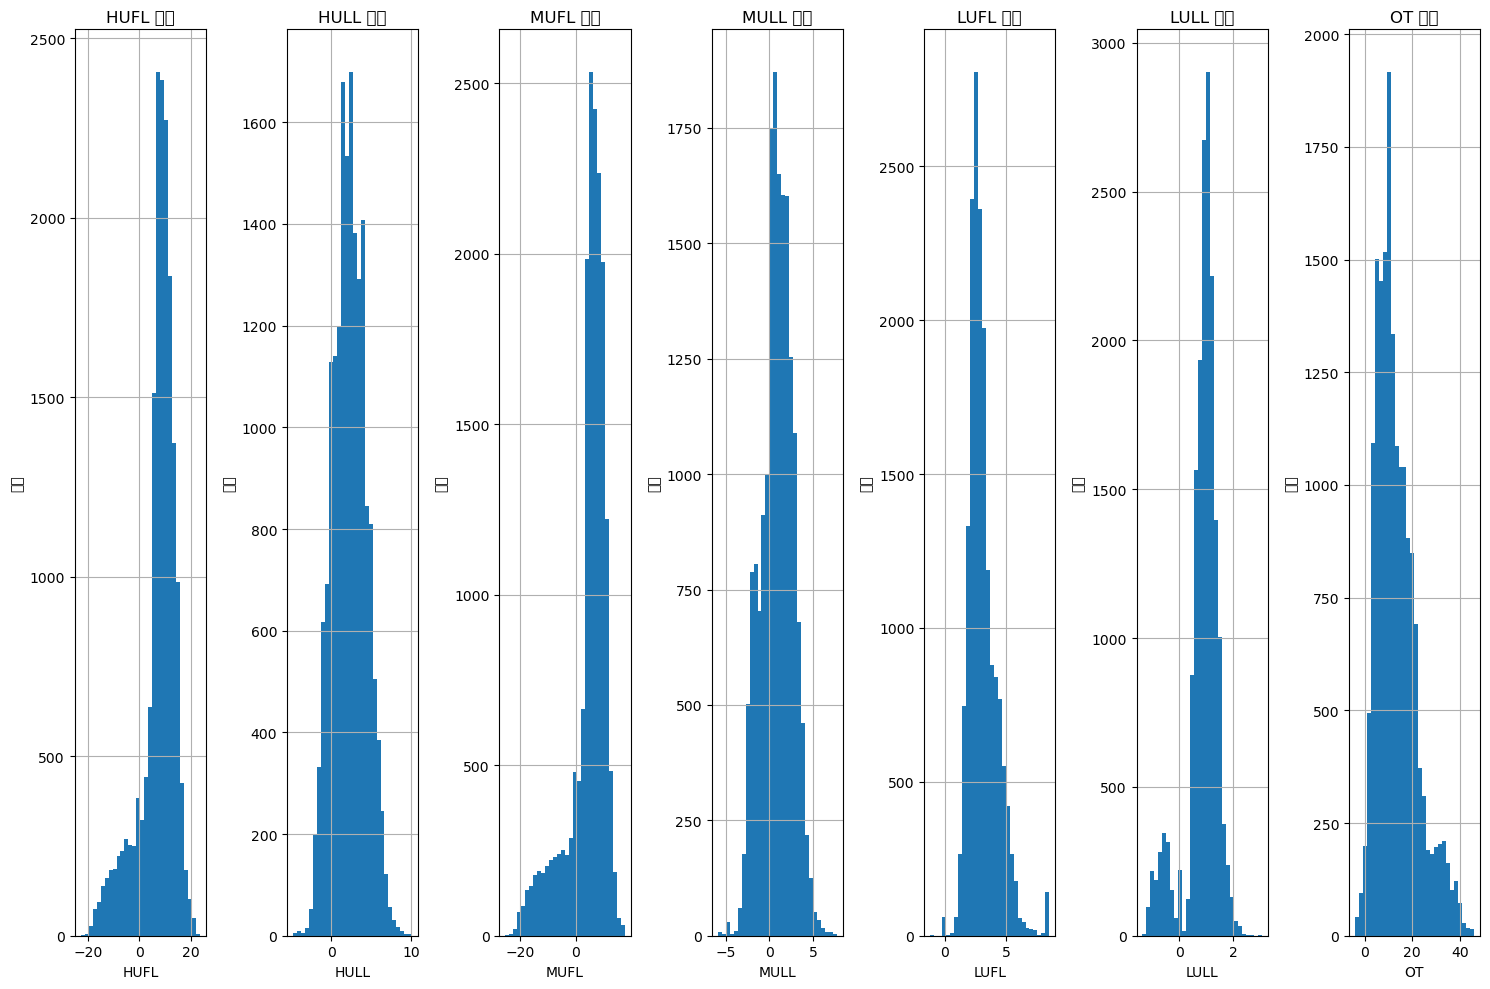

数值型特征详细统计:
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.067744      2.042342      6.826978      1.809293      1.164506   
min      -22.705999     -4.756000    -25.087999     -5.934000     -1.188000   
25%        5.827000      0.737000      3.296000     -0.284000      2.315000   
50%        8.774000      2.210000      5.970000      0.959000      2.833000   
75%       11.788000      3.684000      8.635000      2.203000      3.625000   
max       23.643999     10.114000     17.341000      7.747000      8.498000   

               LULL            OT  
count  17420.000000  17420.000000  
mean       0.856932     13.324672  
std        0.599552      8.566946  
min       -1.371000     -4.080000  
25%        0.670000      6.964000  
50%        0.975000     11.396000  
75%        1.218000     1

In [13]:
# 选择数值型特征
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# 绘制数值型特征的分布
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_features):  
    df[col].hist(bins=30, ax=axes[i])
    axes[i].set_title(f'{col} 分布')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('频数')

plt.tight_layout()
plt.show()

# 检查数值型特征的统计信息
print("数值型特征详细统计:")
print(df[numeric_features].describe())

c:\Users\cyt\anaconda3\envs\data_science\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cyt\anaconda3\envs\data_science\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cyt\anaconda3\envs\data_science\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cyt\anaconda3\envs\data_science\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cyt\anaconda3\envs\data_science\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarni

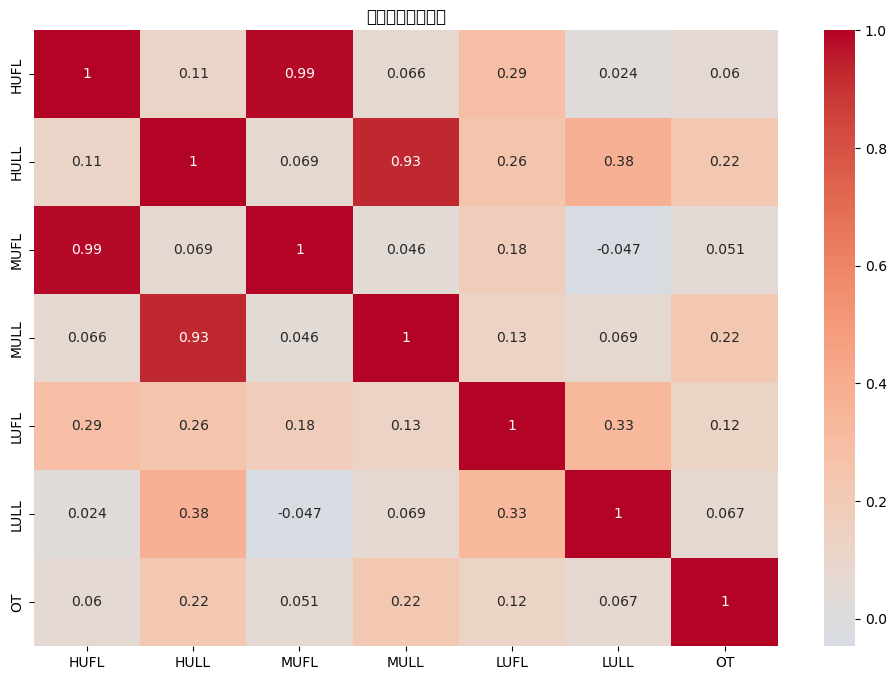

In [14]:
# 数值型特征的相关性矩阵
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('特征相关性热力图')
plt.show()

# # 找出与目标变量相关性高的特征
# if 'target' in df.columns:
#     target_corr = df[numeric_features].corrwith(df['target']).abs().sort_values(ascending=False)
#     print("与目标变量的相关性排序:")
#     print(target_corr)